In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
real = pd.read_csv("../data/True.csv")
fake = pd.read_csv("../data/Fake.csv")

# Etiquetar
real["label"] = 1  # 1 = Real
fake["label"] = 0  # 0 = Fake

# Unir y mezclar
df = pd.concat([real, fake]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total noticias: {len(df)}")
print(f"Reales: {len(real)} | Falsas: {len(fake)}")
df.head()

Total noticias: 44898
Reales: 21417 | Falsas: 23481


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [3]:
print(df.info())
print("\nValores nulos:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB
None

Valores nulos:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


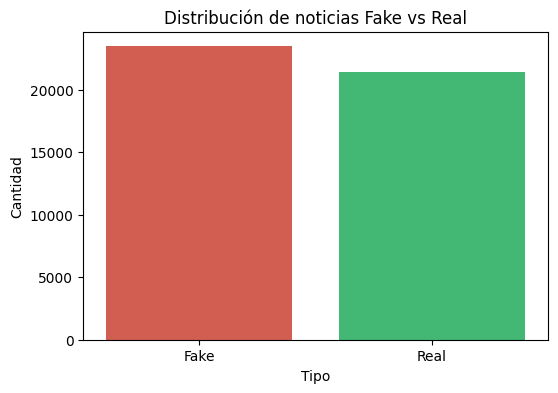

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["Fake", "Real"])
plt.title("Distribución de noticias Fake vs Real")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.savefig("../outputs/distribucion_clases.png", dpi=150, bbox_inches='tight')
plt.show()

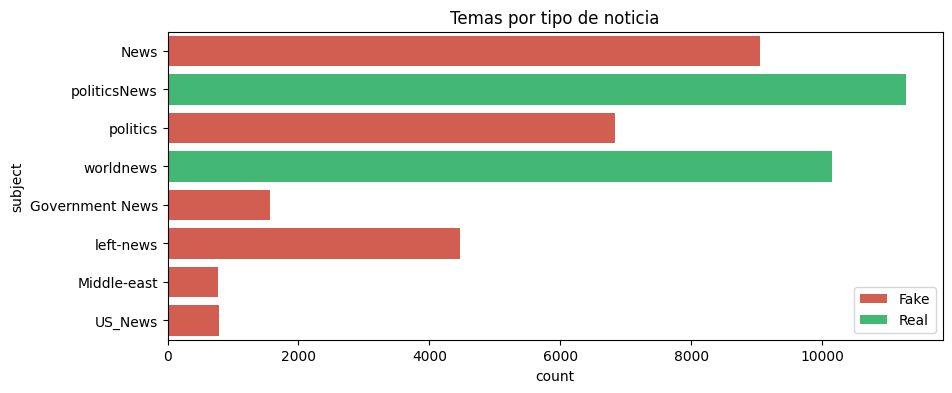

In [5]:
plt.figure(figsize=(10, 4))
sns.countplot(y="subject", hue="label", data=df, palette=["#e74c3c", "#2ecc71"])
plt.title("Temas por tipo de noticia")
plt.legend(["Fake", "Real"])
plt.savefig("../outputs/distribucion_temas.png", dpi=150, bbox_inches='tight')
plt.show()

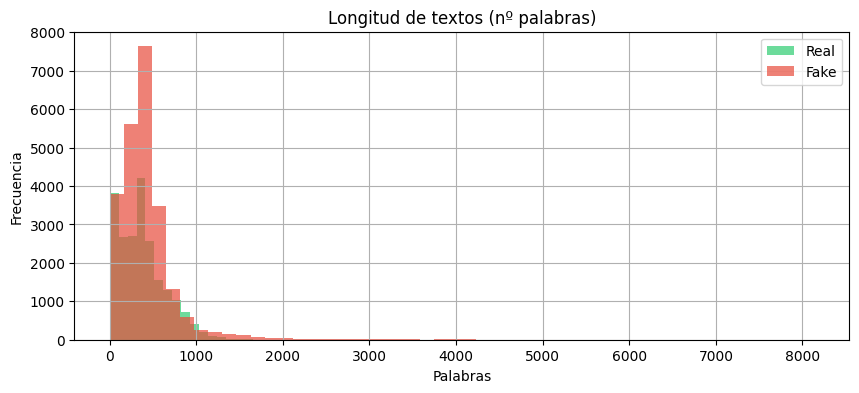

         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      23481.0  423.197905  408.388890  0.0  240.0  363.0  506.0  8135.0
1      21417.0  385.640099  274.006204  0.0  148.0  359.0  525.0  5172.0


In [6]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
df[df["label"] == 1]["text_length"].hist(bins=50, alpha=0.7, color="#2ecc71", label="Real")
df[df["label"] == 0]["text_length"].hist(bins=50, alpha=0.7, color="#e74c3c", label="Fake")
plt.title("Longitud de textos (nº palabras)")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.legend()
plt.savefig("../outputs/longitud_textos.png", dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby("label")["text_length"].describe())

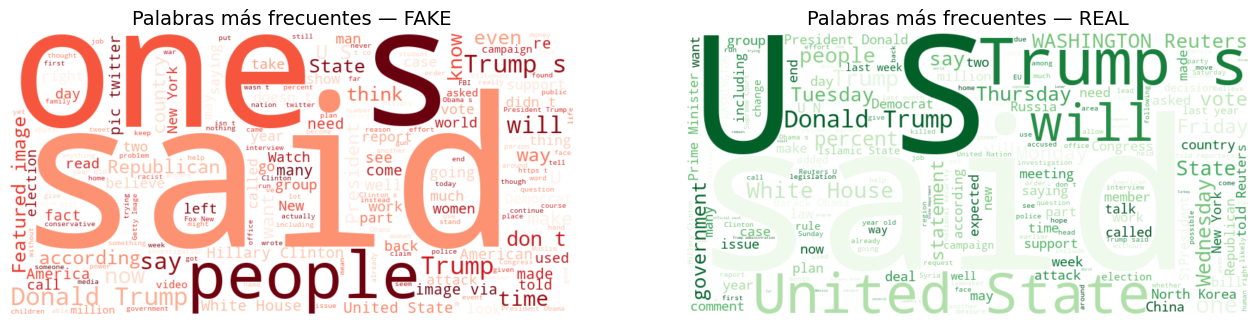

In [7]:
# Noticias FAKE
fake_text = " ".join(df[df["label"] == 0]["text"].astype(str))
wc_fake = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(fake_text)

# Noticias REAL
real_text = " ".join(df[df["label"] == 1]["text"].astype(str))
wc_real = WordCloud(width=800, height=400, background_color="white", colormap="Greens").generate(real_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(wc_fake, interpolation="bilinear")
axes[0].set_title("Palabras más frecuentes — FAKE", fontsize=14)
axes[0].axis("off")

axes[1].imshow(wc_real, interpolation="bilinear")
axes[1].set_title("Palabras más frecuentes — REAL", fontsize=14)
axes[1].axis("off")

plt.savefig("../outputs/wordclouds.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
df.to_csv("../data/dataset_combinado.csv", index=False)
print("✅ Dataset guardado en /data/dataset_combinado.csv")

✅ Dataset guardado en /data/dataset_combinado.csv
